### Khang Tran Homework 08 Deep Learning

In [5]:
import torch
torch.__version__

'2.9.1+cu128'

## Download dataset

In [6]:
# !wget https://github.com/SVizor42/ML_Zoomcamp/releases/download/straight-curly-data/data.zip;
# !unzip data.zip;

In [7]:
from PIL import Image
import numpy as np
import torchvision
import os
import random

import numpy as np
import torch

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [8]:
### Define the curly path
curly_path = 'data/train/curly'
straight_path = 'data/train/straight'

### Get a list of all files in the folder
all_curly_files = os.listdir(curly_path)
all_straight_files = os.listdir(straight_path)

### Choose a random file from the list of curly files
curly_example = np.random.choice(all_curly_files)
curly_example = os.path.join(curly_path, curly_example)
straight_example = np.random.choice(all_straight_files)
straight_example = os.path.join(straight_path, straight_example)

print('Number of CURLY train data: ',len(all_curly_files))
print('Number of STRAIGHT train data: ',len(all_straight_files))
print('TOTAL train data: ',len(all_curly_files)+len(all_straight_files))
print('_' * 50)
print('Number of CURLY test data: ',len(os.listdir('data/test/curly')))
print('Number of STRAIGHT test data: ',len(os.listdir('data/test/straight')))
print('TOTAL test data: ',len(os.listdir('data/test/curly'))+len(os.listdir('data/test/straight')))

Number of CURLY train data:  411
Number of STRAIGHT train data:  390
TOTAL train data:  801
__________________________________________________
Number of CURLY test data:  103
Number of STRAIGHT test data:  98
TOTAL test data:  201


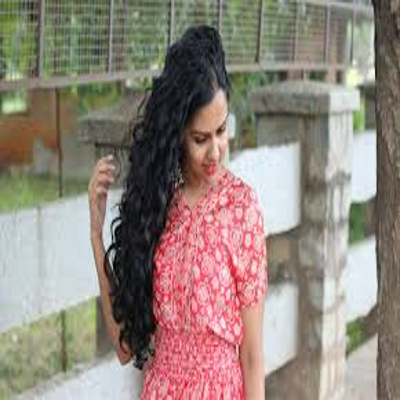

In [9]:
curly = Image.open(curly_example)
curly.resize((400,400))

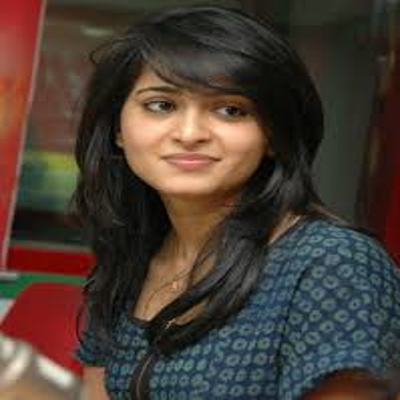

In [10]:
straight = Image.open(straight_example)
straight.resize((400,400))

## Transformation

In [11]:
import torchvision.transforms as transforms

train_transforms = transforms.Compose([
    transforms.Resize((200, 200)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ) # ImageNet normalization
])

train_transforms

Compose(
    Resize(size=(200, 200), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)

## Dataset

In [12]:
from torch.utils.data import Dataset, DataLoader

class HairDataset(Dataset):
  def __init__(self, root_dir, transform=None):
    self.root_dir = root_dir
    self.transform = transform
    self.image_paths = []
    self.labels = []

    ### Add curly = label (0), straight = label (1)
    for label, subdir in enumerate(['curly', 'straight']):
      subdir_path = os.path.join(root_dir, subdir)
      for img_name in os.listdir(subdir_path):
        self.image_paths.append(os.path.join(subdir_path, img_name))
        self.labels.append(label)

  def __len__(self):
    return len(self.image_paths)

  def __getitem__(self, idx):
    img_path = self.image_paths[idx]
    label = self.labels[idx]
    ### Open Image
    image = Image.open(img_path).convert('RGB')
    if self.transform:
      image = self.transform(image)
    return image, label

train_dataset = HairDataset('data/train', transform=train_transforms)
test_dataset = HairDataset('data/test', transform=train_transforms)

## DataLoader

In [13]:
train_loader = DataLoader(train_dataset, batch_size=20, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=20, shuffle=False)

In [14]:
import torch.nn as nn
class BinaryHairClassifier(nn.Module):
  def __init__(self):
    super().__init__()

    ### Convolutional layer
    self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size= 3, padding = 0, stride = 1)
    self.relu = nn.ReLU()
    self.maxpool = nn.MaxPool2d(kernel_size=2, stride = 2)

    ### Using flatten
    self.flatten = nn.Flatten()

    ### Fully connected layer
    # Corrected input features for the first linear layer
    self.fc = nn.Linear(32 * 99 * 99, 64) # 32 channels * 99x99 feature map size
    self.relu2 = nn.ReLU() # Renamed to avoid conflict with self.relu
    self.fc2 = nn.Linear(64,1)
    self.sigmoid = nn.Sigmoid() # Added Sigmoid activation

  def forward(self, x):
    x = self.conv1(x)
    x = self.relu(x)
    x = self.maxpool(x)
    x = self.flatten(x)
    x = self.fc(x)
    x = self.relu2(x) # Using relu2
    x = self.fc2(x)
    x = self.sigmoid(x)
    return x

model = BinaryHairClassifier()
model

BinaryHairClassifier(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1))
  (relu): ReLU()
  (maxpool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc): Linear(in_features=313632, out_features=64, bias=True)
  (relu2): ReLU()
  (fc2): Linear(in_features=64, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)

## Loss

In [15]:
criterion = nn.BCEWithLogitsLoss()
criterion

BCEWithLogitsLoss()

## Optimizer

In [16]:
import torch.optim as optim
optimizer = optim.SGD(model.parameters(), lr=0.002, momentum=0.8)
optimizer

SGD (
Parameter Group 0
    dampening: 0
    differentiable: False
    foreach: None
    fused: None
    lr: 0.002
    maximize: False
    momentum: 0.8
    nesterov: False
    weight_decay: 0
)

## Device

In [17]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
device

device(type='cpu')

## Question 2:
Number of parameters

* 896
* 11214912
* 15896912
* 20073473

In [18]:
total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params}")

Total parameters: 20073473


In [19]:
from torchsummary import summary
summary(model, input_size=(3, 200, 200), device = device.type)

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 32, 198, 198]             896
              ReLU-2         [-1, 32, 198, 198]               0
         MaxPool2d-3           [-1, 32, 99, 99]               0
           Flatten-4               [-1, 313632]               0
            Linear-5                   [-1, 64]      20,072,512
              ReLU-6                   [-1, 64]               0
            Linear-7                    [-1, 1]              65
           Sigmoid-8                    [-1, 1]               0
Total params: 20,073,473
Trainable params: 20,073,473
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.46
Forward/backward pass size (MB): 23.93
Params size (MB): 76.57
Estimated Total Size (MB): 100.96
----------------------------------------------------------------


## Fit the model:

In [20]:
num_epochs = 10
history = {'acc': [], 'loss': [], 'test_loss': [], 'test_acc': []}

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        labels = labels.float().unsqueeze(1) # Ensure labels are float and have shape (batch_size, 1)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        # For binary classification with BCEWithLogitsLoss, apply sigmoid to outputs before thresholding for accuracy
        predicted = (torch.sigmoid(outputs) > 0.5).float()
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(train_dataset)
    epoch_acc = correct_train / total_train
    history['loss'].append(epoch_loss)
    history['acc'].append(epoch_acc)

    model.eval()
    val_running_loss = 0.0
    correct_val = 0
    total_val = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            labels = labels.float().unsqueeze(1)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_running_loss += loss.item() * images.size(0)
            predicted = (torch.sigmoid(outputs) > 0.5).float()
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()

    test_epoch_loss = val_running_loss / len(test_dataset)
    test_epoch_acc = correct_val / total_val
    history['test_loss'].append(test_epoch_loss)
    history['test_acc'].append(test_epoch_acc)

    print(f"Epoch {epoch+1}/{num_epochs}, "
          f"Loss: {epoch_loss:.4f}, Acc: {epoch_acc:.4f}, "
          f"Test Loss: {test_epoch_loss:.4f}, Test Acc: {test_epoch_acc:.4f}")

Epoch 1/10, Loss: 0.6786, Acc: 0.4869, Test Loss: 0.6661, Test Acc: 0.4876
Epoch 2/10, Loss: 0.6556, Acc: 0.4869, Test Loss: 0.6552, Test Acc: 0.4876
Epoch 3/10, Loss: 0.6422, Acc: 0.4869, Test Loss: 0.6652, Test Acc: 0.4925
Epoch 4/10, Loss: 0.6870, Acc: 0.6442, Test Loss: 0.6717, Test Acc: 0.5821
Epoch 5/10, Loss: 0.6632, Acc: 0.5768, Test Loss: 0.6645, Test Acc: 0.6169
Epoch 6/10, Loss: 0.6541, Acc: 0.5855, Test Loss: 0.6564, Test Acc: 0.5920
Epoch 7/10, Loss: 0.6422, Acc: 0.5568, Test Loss: 0.6583, Test Acc: 0.5672
Epoch 8/10, Loss: 0.6470, Acc: 0.5456, Test Loss: 0.6595, Test Acc: 0.5721
Epoch 9/10, Loss: 0.6382, Acc: 0.5418, Test Loss: 0.6592, Test Acc: 0.5572
Epoch 10/10, Loss: 0.6493, Acc: 0.5768, Test Loss: 0.6673, Test Acc: 0.4925


## Question 3:
What is the median of training accuracy for all the epochs for this model?

* 0.05
* 0.12
* 0.40
* 0.84

In [21]:
round(np.median(history['acc']),2)

np.float64(0.55)

## Question 4:
What is the standard deviation of training loss for all the epochs for this model?

* 0.007
* 0.078
* 0.171
* 1.710

In [22]:
round(np.std(history['loss']),2)

np.float64(0.02)

## Data Augmentation:
add augmentation
```python
transforms.RandomRotation(50),
transforms.RandomResizedCrop(200, scale=(0.9, 1.0), ratio=(0.9, 1.1)),
transforms.RandomHorizontalFlip(),
```

In [23]:
train_augmentation = transforms.Compose([
    transforms.Resize((200, 200)),
    transforms.RandomRotation(50),
    transforms.RandomResizedCrop(200, scale=(0.9, 1.0), ratio=(0.9, 1.1)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ) # ImageNet normalization
])

train_augmentation

Compose(
    Resize(size=(200, 200), interpolation=bilinear, max_size=None, antialias=True)
    RandomRotation(degrees=[-50.0, 50.0], interpolation=nearest, expand=False, fill=0)
    RandomResizedCrop(size=(200, 200), scale=(0.9, 1.0), ratio=(0.9, 1.1), interpolation=bilinear, antialias=True)
    RandomHorizontalFlip(p=0.5)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)

In [24]:
train_dataset_aug = HairDataset('data/train', transform=train_augmentation)
train_loader_aug = DataLoader(train_dataset_aug, batch_size=20, shuffle=True)

In [25]:
history_augmentation = {
    'loss': [],
    'acc': [],
    'test_loss': [],
    'test_acc': []}
num_epochs = 10

for epoch in range(num_epochs):
    model.train()
    running_loss = 0
    correct_train = 0
    total_train = 0

    for images, labels in train_loader_aug:  # using augmented data
        images, labels = images.to(device), labels.to(device)
        labels = labels.float().unsqueeze(1)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        predicted = (torch.sigmoid(outputs) > 0.5).float()
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(train_dataset_aug)
    epoch_acc = correct_train / total_train

    # validation / test
    model.eval()
    val_running_loss = 0
    correct_val = 0
    total_val = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            labels = labels.float().unsqueeze(1)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_running_loss += loss.item() * images.size(0)
            predicted = (torch.sigmoid(outputs) > 0.5).float()
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()

    test_epoch_loss = val_running_loss / len(test_dataset)
    test_epoch_acc = correct_val / total_val

    # append to new history
    history_augmentation['loss'].append(epoch_loss)
    history_augmentation['acc'].append(epoch_acc)
    history_augmentation['test_loss'].append(test_epoch_loss)
    history_augmentation['test_acc'].append(test_epoch_acc)

    print(f"Epoch {epoch+1}/{num_epochs}, "
          f"Loss: {epoch_loss:.4f}, Acc: {epoch_acc:.4f}, "
          f"Test Loss: {test_epoch_loss:.4f}, Test Acc: {test_epoch_acc:.4f}")

Epoch 1/10, Loss: 0.6621, Acc: 0.5144, Test Loss: 0.6589, Test Acc: 0.5373
Epoch 2/10, Loss: 0.6613, Acc: 0.5194, Test Loss: 0.6550, Test Acc: 0.5771
Epoch 3/10, Loss: 0.6599, Acc: 0.5368, Test Loss: 0.6548, Test Acc: 0.5672
Epoch 4/10, Loss: 0.6553, Acc: 0.5393, Test Loss: 0.6539, Test Acc: 0.5771
Epoch 5/10, Loss: 0.6516, Acc: 0.5443, Test Loss: 0.6530, Test Acc: 0.5423
Epoch 6/10, Loss: 0.6540, Acc: 0.5243, Test Loss: 0.6548, Test Acc: 0.5771
Epoch 7/10, Loss: 0.6535, Acc: 0.5368, Test Loss: 0.6557, Test Acc: 0.5821
Epoch 8/10, Loss: 0.6639, Acc: 0.5630, Test Loss: 0.6518, Test Acc: 0.5522
Epoch 9/10, Loss: 0.6495, Acc: 0.5306, Test Loss: 0.6536, Test Acc: 0.5771
Epoch 10/10, Loss: 0.6470, Acc: 0.5518, Test Loss: 0.6540, Test Acc: 0.6020


## Question 5:
What is the mean of test loss for all the epochs for the model trained with augmentations?
* 0.008
* 0.08
* 0.88
* 8.88

In [26]:
round(np.mean(history_augmentation['test_loss']),2)

np.float64(0.65)

## Question 6:
What's the average of test accuracy for the last 5 epochs (from 6 to 10)
for the model trained with augmentations?

* 0.08
* 0.28
* 0.68
* 0.98

In [27]:
round(np.mean(history_augmentation['test_acc'][5:]),2)

np.float64(0.58)